# Customer booking data

### Loading and inspecting
Import the necessary packages


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

Load the customer_booking data in a DataFrame named `bookings` and show the first 5 rows to inspect the DataFrame.

In [2]:
df = pd.read_csv("customer_booking.csv", index_col=0)
df.head(10)

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0
5,1,Internet,RoundTrip,3,48,20,Thu,AKLDEL,New Zealand,1,0,1,5.52,0
6,3,Internet,RoundTrip,201,33,6,Thu,AKLDEL,New Zealand,1,0,1,5.52,0
7,2,Internet,RoundTrip,238,19,14,Mon,AKLDEL,India,1,0,1,5.52,0
8,1,Internet,RoundTrip,80,22,4,Mon,AKLDEL,New Zealand,0,0,1,5.52,0
9,1,Mobile,RoundTrip,378,30,12,Sun,AKLDEL,India,0,0,0,5.52,0


In [3]:
df.dtypes

num_passengers             int64
sales_channel             object
trip_type                 object
purchase_lead              int64
length_of_stay             int64
flight_hour                int64
flight_day                object
route                     object
booking_origin            object
wants_extra_baggage        int64
wants_preferred_seat       int64
wants_in_flight_meals      int64
flight_duration          float64
booking_complete           int64
dtype: object

**Information about the dataframe**
  
  
This dataset contains information about airline bookings, including the number of passengers, sales channel, trip type, purchase lead time, length of stay, flight hour, flight day, route, booking origin, and various flags indicating if the customer wanted extra baggage, preferred seat, or in-flight meals. The dataset also includes the total flight duration and a flag indicating if the booking was completed. This information can be used for various analyses, such as predicting demand, identifying popular routes, and understanding customer preferences.

**Column Description**:
* num_passengers = number of passengers travelling
* sales_channel = sales channel booking was made on
* trip_type = trip Type (Round Trip, One Way, Circle Trip)
* purchase_lead = number of days between travel date and booking date
* length_of_stay = number of days spent at destination
* flight_hour = hour of flight departure
* flight_day = day of week of flight departure
* route = origin -> destination flight route
* booking_origin = country from where booking was made
* wants_extra_baggage = if the customer wanted extra baggage in the booking
* wants_preferred_seat = if the customer wanted a preferred seat in the booking
* wants_in_flight_meals = if the customer wanted in-flight meals in the booking
* flight_duration = total duration of flight (in hours)
* booking_complete = flag indicating if the customer completed the booking

### Completed bookings

Create a new dataframe named `completed_bookings`:
* only containing following columns:  
num_passengers, purchase_lead, length_of_stay, booking_origin, flight_duration and booking_complete
* with only the rows where the booking is completed (1)


In [4]:
complete_bookings = df[df['booking_complete'] == 1][['num_passengers', 'purchase_lead', 'length_of_stay', 'booking_origin', 'flight_duration', 'booking_complete']]
complete_bookings.head()

,num_passengers,purchase_lead,length_of_stay,booking_origin,flight_duration,booking_complete
82,1,15,31,Malaysia,8.83,1
86,1,156,19,Malaysia,8.83,1
94,1,181,87,Singapore,8.83,1
109,1,127,17,Malaysia,8.83,1
122,1,42,17,Malaysia,8.83,1


In [5]:
complete_bookings.shape

(7478, 6)

#### Average purchase lead

Group the average days between booking date and traveling date per country of the booking. Display the countries with the lowest average of days between booking and traveling first and the ones with the most days last.

In [6]:
grouped_by_country = pd.DataFrame(df.groupby(by='booking_origin')['purchase_lead']
                        .mean()).sort_values(by=['purchase_lead'])

grouped_by_country.columns = ['avg_purchase_lead']
grouped_by_country

,avg_purchase_lead
booking_origin,
Tanzania,10.000000
Vanuatu,11.000000
Israel,12.000000
Kenya,12.666667
Belarus,15.000000
...,...
Nicaragua,168.000000
Cyprus,172.500000
Afghanistan,191.000000


Display the average amount of days between booking date and flight date of Australia.

In [7]:
grouped_by_country.loc['Australia']

avg_purchase_lead    78.579622
Name: Australia, dtype: float64

In [8]:
grouped_by_country.at['Australia', 'avg_purchase_lead']

78.57962175470009

## Purchase lead histogram
Make a histogram (bar plot) of the purchase leads per country. Do this for the 5 countries with the most bookings. Place the purchase leads on the x-axis and the number of bookings on the y-axis. Use appropriate labels and show a legend.

**step 1** find the 5 countries with the most bookings and store them in a variable `countries`.

In [9]:
countries = pd.DataFrame(df.groupby(by='booking_origin')['booking_origin'].count().sort_values(ascending=False)).head(5)
countries.index.name = 'country'
countries.columns = ['booking_count']
countries

,booking_count
country,
Australia,17872
Malaysia,7174
South Korea,4559
Japan,3885
China,3387


**step 2** Create a barplot for every country. Ensure you use appropriate labels and a legend.

In [10]:
countries['avg_purchase_lead'] = grouped_by_country.loc[countries.index]
countries

,booking_count,avg_purchase_lead
country,,
Australia,17872,78.579622
Malaysia,7174,87.526206
South Korea,4559,91.425971
Japan,3885,79.916345
China,3387,80.353115


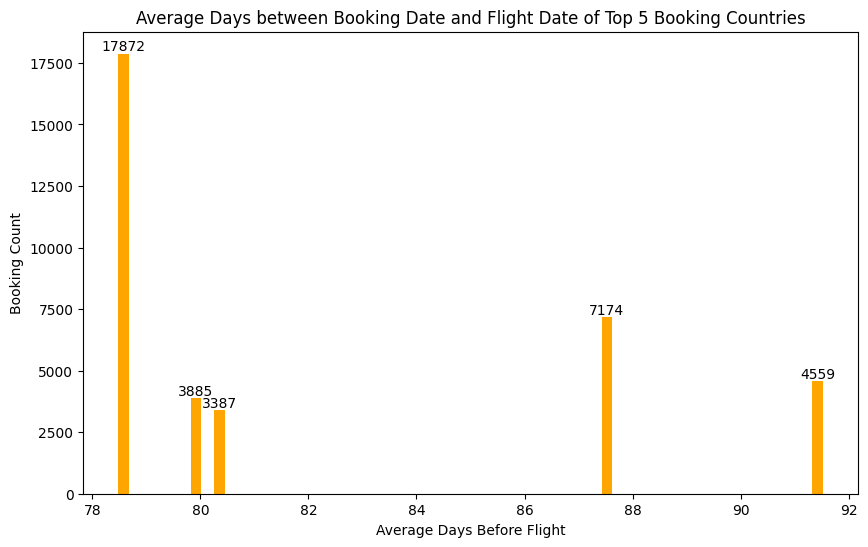

In [11]:
plt.figure(figsize=(10, 6))

avg = plt.bar(countries['avg_purchase_lead'], countries['booking_count'], width=0.2, color='orange', align='center')
plt.bar_label(avg)
plt.xlabel('Average Days Before Flight')
plt.ylabel('Booking Count')
plt.title('Average Days between Booking Date and Flight Date of Top 5 Booking Countries')

plt.show()


The graph above is not really practical. First of all,  all the bins are very small so it is hard to read. Besides, bars with the same x-value are drawn on top of each other. This causes some bars to be invisible. Furthermore, we have a wide x-axis range with just a few data points above 500.
Let's try to make a cleaner graph.

## Try again
**Assignment**
Make a new histogram (bar plot) of the categorical purchase leads per country. Do this for the 5 countries with the most bookings. Place the purchase leads categories on the x-axis and the number of bookings on the y-axis. Use appropriate labels and show a legend.
### Categorizing purchase leads

Let's first categorize the purchase leads using following categories:
purchase lead
* more than 365 days before departure --> early bird
* 365 days or less in advance but more than 183 days in advance --> planner
* Booked more than 90 days prior to departure but at most 183 prior to departure --> seasonal booker
* Booked at most 90 days in advance --> late booker
* less than 2 weeks in advance --> last minute


In [12]:
def classify_purchase_lead(days):
    if days > 365:
        return 'early bird'
    elif days > 183:
        return 'planner'
    elif days > 90:
        return 'seasonal booker'
    elif days >= 14:
        return 'late booker'
    else:
        return 'last minute'

Add a new column "purchase_lead_category" in the completed_bookings dataframe containing the corresponding categories.

In [13]:
complete_bookings['purchase_lead_category'] = complete_bookings['purchase_lead'].apply(classify_purchase_lead)
complete_bookings

,num_passengers,purchase_lead,length_of_stay,booking_origin,flight_duration,booking_complete,purchase_lead_category
82,1,15,31,Malaysia,8.83,1,late booker
86,1,156,19,Malaysia,8.83,1,seasonal booker
94,1,181,87,Singapore,8.83,1,seasonal booker
109,1,127,17,Malaysia,8.83,1,seasonal booker
122,1,42,17,Malaysia,8.83,1,late booker
...,...,...,...,...,...,...,...
49972,1,33,6,Taiwan,4.67,1,late booker
49977,2,15,6,Malaysia,4.67,1,late booker
49980,4,242,6,Malaysia,5.00,1,planner
49984,2,7,6,Australia,5.62,1,last minute


Store the distinct categories in a variable named `pl_categories`, ordered from "last minute" to "early bird".

In [14]:
pl_categories = ['last minute', 'late booker', 'seasonal booker', 'planner', 'early bird']

### Distinct dataframe top 5 
Create a new dataframe `top_df` containing the data of the top 5 countries with the most bookings.

Tip: use the variable `countries`which you already made.

In [15]:
top_df = df.groupby(by='booking_origin')['booking_origin'].count().sort_values(ascending=False).head(5)
top_df.index.name = 'country'
top_df = top_df.index.to_list()
top_df

['Australia', 'Malaysia', 'South Korea', 'Japan', 'China']

Display the total amount of purchase leads in every purchase_lead_category per country. Store this in a variable.

In [16]:
complete_bookings

,num_passengers,purchase_lead,length_of_stay,booking_origin,flight_duration,booking_complete,purchase_lead_category
82,1,15,31,Malaysia,8.83,1,late booker
86,1,156,19,Malaysia,8.83,1,seasonal booker
94,1,181,87,Singapore,8.83,1,seasonal booker
109,1,127,17,Malaysia,8.83,1,seasonal booker
122,1,42,17,Malaysia,8.83,1,late booker
...,...,...,...,...,...,...,...
49972,1,33,6,Taiwan,4.67,1,late booker
49977,2,15,6,Malaysia,4.67,1,late booker
49980,4,242,6,Malaysia,5.00,1,planner
49984,2,7,6,Australia,5.62,1,last minute


In [17]:
per_country_per_cat = pd.DataFrame(complete_bookings[complete_bookings['booking_origin'].isin(top_df)])
per_country_per_cat

,num_passengers,purchase_lead,length_of_stay,booking_origin,flight_duration,booking_complete,purchase_lead_category
82,1,15,31,Malaysia,8.83,1,late booker
86,1,156,19,Malaysia,8.83,1,seasonal booker
109,1,127,17,Malaysia,8.83,1,seasonal booker
122,1,42,17,Malaysia,8.83,1,late booker
124,1,22,180,Malaysia,8.83,1,late booker
...,...,...,...,...,...,...,...
49971,2,38,6,Malaysia,4.67,1,late booker
49977,2,15,6,Malaysia,4.67,1,late booker
49980,4,242,6,Malaysia,5.00,1,planner
49984,2,7,6,Australia,5.62,1,last minute


In [18]:
table = pd.pivot_table(per_country_per_cat, values='purchase_lead', index=['purchase_lead_category'],
                       columns=['booking_origin'], aggfunc="sum")
table = table.reindex(index=pl_categories, columns=top_df)
table

booking_origin,Australia,Malaysia,South Korea,Japan,China
purchase_lead_category,,,,,
last minute,1452,3399,481,690,599
late booker,21860,46796,10492,13091,19001
seasonal booker,14301,52943,9772,7774,17426
planner,14852,91118,12246,7782,16728
early bird,1523,18289,4896,1998,1178


### Grouped bar plot
We want to display the data for every country using grouped bar charts. In order to evenly display the bars, we have to set the locations of our bars.



Now it is time for you to draw the plot. Keep in mind
* Bars cannot overlap
* The order of countries is preserved (meaning the order of countries is the same for all categories)
* The order of the x value categories should be the same as the order stored in the list `pl_categories`
* Ensure the counts per country are plotted in the right category (the order on the x-axis might not be the same as the order in your dataset)
* Provide labels and a legend
* Rotate the x-axis labels to make them readable

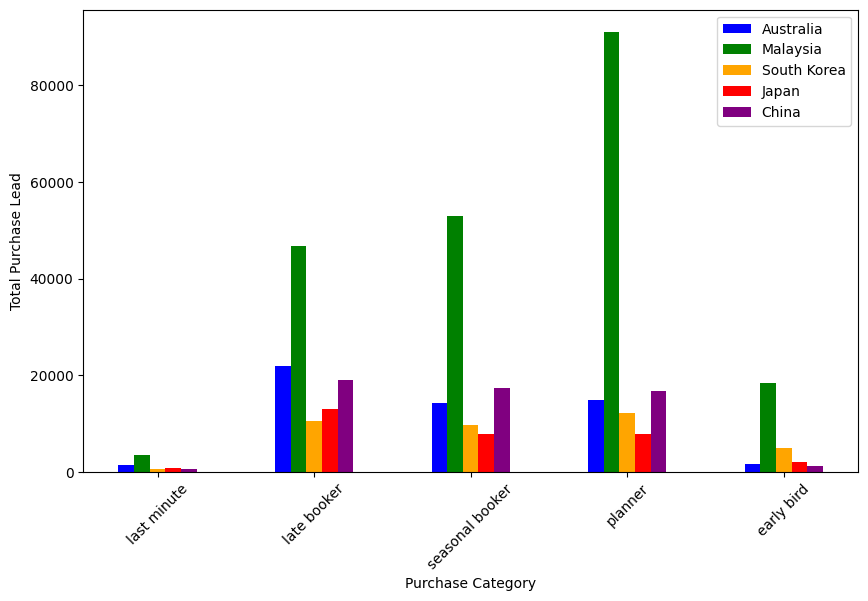

In [19]:
index = range(len(pl_categories))
bar_width = 0.1

plt.figure(figsize=(10, 6))

australia = plt.bar([i - 2*bar_width for i in index],
                    table['Australia'],
                    bar_width,
                    color='blue',
                    label='Australia',
                    align='center')
malaysia = plt.bar([i - bar_width for i in index],
                    table['Malaysia'],
                    bar_width,
                    color='green',
                    label='Malaysia',
                    align='center')
south_korea = plt.bar(index,
                    table['South Korea'],
                    bar_width,
                    color='orange',
                    label='South Korea',
                    align='center')
japan = plt.bar([i + bar_width for i in index],
                    table['Japan'],
                    bar_width,
                    color='red',
                    label='Japan',
                    align='center')
china = plt.bar([i + 2*bar_width for i in index],
                    table['China'],
                    bar_width,
                    color='purple',
                    label='China',
                    align='center')

# plt.bar_label(australia)
# plt.bar_label(malaysia)
# plt.bar_label(south_korea)
# plt.bar_label(japan)
# plt.bar_label(china)

plt.xticks(index,labels=pl_categories, rotation=45)
plt.xlabel('Purchase Category')
plt.ylabel('Total Purchase Lead')

plt.legend()

plt.show()

The image `PurchaseLeadCat_top5.png` displays the expected plot.

## Bookings

For the questions below, work with the `bookings` dataframe.

* Remove bookings with missing values
* Create a new column `duration_cat` indicating whether a flight is "Short", "Medium" or "Long" distance. Short distance flights take at most 3 hours, long distance flights take more than 6 hours.
* Create a new column `premium_customer`. A customer is a premium customer if they want extra baggage, preferred seating and in-flight meals. 


In [20]:
df = df.dropna()

In [21]:
def classify_flight_duration(duration):
    if duration > 6:
        return 'long'
    elif duration > 3:
        return 'medium'
    else:
        return 'short'

In [22]:
df['duration_cat'] = df['flight_duration'].apply(classify_flight_duration)
df

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,duration_cat
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0,medium
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0,medium
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0,medium
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0,medium
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2,Internet,RoundTrip,27,6,9,Sat,PERPNH,Australia,1,0,1,5.62,0,medium
49996,1,Internet,RoundTrip,111,6,4,Sun,PERPNH,Australia,0,0,0,5.62,0,medium
49997,1,Internet,RoundTrip,24,6,22,Sat,PERPNH,Australia,0,0,1,5.62,0,medium
49998,1,Internet,RoundTrip,15,6,11,Mon,PERPNH,Australia,1,0,1,5.62,0,medium


In [23]:
df['premium_customer'] = (df[['wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals']].sum(axis=1) == 3).astype(int)
# df['premium_customer'] = df[['wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals']].all(axis=1).astype(int)
df

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,duration_cat,premium_customer
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0,medium,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0,medium,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0,medium,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0,medium,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0,medium,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2,Internet,RoundTrip,27,6,9,Sat,PERPNH,Australia,1,0,1,5.62,0,medium,0
49996,1,Internet,RoundTrip,111,6,4,Sun,PERPNH,Australia,0,0,0,5.62,0,medium,0
49997,1,Internet,RoundTrip,24,6,22,Sat,PERPNH,Australia,0,0,1,5.62,0,medium,0
49998,1,Internet,RoundTrip,15,6,11,Mon,PERPNH,Australia,1,0,1,5.62,0,medium,0


* Display summary statistics
* What percentage of bookings are completed vs incomplete?
* Which sales channel has the highest percentage of completion?
* What percentage of long distance travellers who completed their booking are premium customers? (You do not need to take into account the amount of travellers per booking.)
* What are the top 5 most popular routes based on the number of passengers?
* Display the average flight duration per country

In [24]:
# Summary statistics
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,premium_customer
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560,0.175400
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643,0.380313
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000,1.000000


In [27]:
# Percentage completed vs incomplete
df['booking_complete'].value_counts() / df.shape[0] * 100

booking_complete
0    85.044
1    14.956
Name: count, dtype: float64

In [31]:
# Percentage of completion per sales channel
complete_df = df[df['booking_complete'] == 1]
complete_df.groupby('sales_channel')['sales_channel'].count() / complete_df.shape[0] * 100

sales_channel
Internet    91.856111
Mobile       8.143889
Name: sales_channel, dtype: float64

In [35]:
# Premium customers long distance
filtered = df[(df['duration_cat'] == 'long') & (df['booking_complete'] == 1) & (df['premium_customer'] == 1)]
filtered.shape[0] / df.shape[0] * 100

2.5100000000000002

In [41]:
# Top 5 routes
grouped_by_route = pd.DataFrame(df.groupby('route')['num_passengers'].sum()).sort_values('num_passengers', ascending=False)
grouped_by_route.head(5)

,num_passengers
route,
AKLKUL,4450
PENTPE,1566
DMKKIX,1428
ICNSIN,1335
MELSGN,1230


In [44]:
# Flight duration
grouped_by_country = pd.DataFrame(
    df.groupby('booking_origin')['flight_hour'].mean()
).sort_values('flight_hour', ascending=False)
grouped_by_country.columns = ['avg_flight_duration']
grouped_by_country

,avg_flight_duration
booking_origin,
Gibraltar,23.0
Ghana,22.0
Vanuatu,21.0
Malta,21.0
Egypt,21.0
...,...
Pakistan,3.0
Seychelles,3.0
Lebanon,3.0
